<a href="https://colab.research.google.com/github/akashkalamulla/Akash-portfolio-master/blob/main/Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# CELL 0 — SURGICAL FIX (HF stack only)
# ==========================================================
!pip -q uninstall -y diffusers transformers accelerate huggingface_hub safetensors tokenizers
!pip -q install -q --upgrade "huggingface_hub>=0.33.5,<0.36.0"
!pip -q install -q --upgrade "transformers>=4.45.0,<4.49.0" "accelerate>=0.26.0" "safetensors>=0.4.5" "tokenizers>=0.20.0"
!pip -q install -q --upgrade "diffusers>=0.33.0,<0.37.0"

# Pillow + numpy: DO NOT fight the whole runtime. Keep what Colab already wants.
import importlib, sys
print("✅ HF stack reinstalled. NOW: Runtime > Restart runtime (MANDATORY).")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, which is not installed.
peft 0.18.1 requires accelerate>=0.21.0, which is not installed.
peft 0.18.1 requires safetensors, which is not installed.
peft 0.18.1 requires transformers, which is not installed.
torchtune 0.6.1 requires safetensors, which is not installed.
torchtune 0.6.1 requires tokenizers, which is not installed.
timm 1.0.24 requires safetensors, which is not installed.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
✅ HF stack reinstalled. NOW: Runtime > Restart runtime (MANDATORY).


In [ ]:
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

In [ ]:
# ==========================================================
# 1) MOUNT DRIVE
# ==========================================================
from google.colab import drive
drive.mount("/content/drive")

MessageError: Error: credential propagation was unsuccessful

In [ ]:

import os, sys, glob
PROJECT_ROOT = "/content/drive/MyDrive/AI_Trichologist"
assert os.path.isdir(PROJECT_ROOT), f"PROJECT_ROOT missing: {PROJECT_ROOT}"

# Try the path you claimed
KB_PATH = f"{PROJECT_ROOT}/knowledgebase"

candidates = []
if os.path.isdir(KB_PATH):
    candidates.append(KB_PATH)

# Brutal fallback search: find reasoning_engine.py anywhere under project root
found = glob.glob(f"{PROJECT_ROOT}/**/reasoning_engine.py", recursive=True)
for p in found:
    candidates.append(os.path.dirname(p))

# De-dup
candidates = list(dict.fromkeys(candidates))
print("KB candidates:", candidates)

# Add all candidates to sys.path (first one wins imports)
for c in candidates:
    if c not in sys.path:
        sys.path.insert(0, c)

# Now import
from reasoning_engine import recommend_from_meta
print("✅ reasoning_engine imported from:", os.path.dirname(__import__("reasoning_engine").__file__))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
KB candidates: ['/content/drive/MyDrive/AI_Trichologist/knowledgebase', '/content/drive/MyDrive/AI_Trichologist/knowledgebase/scripts']
✅ reasoning_engine imported from: /content/drive/MyDrive/AI_Trichologist/knowledgebase/scripts


In [ ]:
# ==========================================================
# C) IMPORT DIFFUSERS — should work now
# ==========================================================
import torch
from diffusers import StableDiffusionInpaintPipeline
print("✅ diffusers import OK")

/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


✅ diffusers import OK


In [ ]:
import torch
from diffusers import StableDiffusionInpaintPipeline

SD_INPAINT_MODEL = "runwayml/stable-diffusion-inpainting"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    SD_INPAINT_MODEL,
    torch_dtype=dtype,
    safety_checker=None,
)
pipe = pipe.to(device)
pipe.enable_attention_slicing()

try:
    pipe.enable_xformers_memory_efficient_attention()
    print("✅ xformers enabled")
except Exception as e:
    print("ℹ️ xformers not enabled:", e)

print("✅ SD loaded:", SD_INPAINT_MODEL, "| device:", device, "| dtype:", dtype)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior 

ℹ️ xformers not enabled: Refer to https://github.com/facebookresearch/xformers for more information on how to install xformers
✅ SD loaded: runwayml/stable-diffusion-inpainting | device: cpu | dtype: torch.float32


In [ ]:
import json, re
import numpy as np
from PIL import Image
from pathlib import Path

REQUIRED_PROMPT_KEYS = ["positive","negative","cfg","steps","denoise","seed","constraints"]

def _hard_assert(cond: bool, msg: str):
    if not cond:
        raise RuntimeError(msg)

def load_json(path: str) -> dict:
    _hard_assert(os.path.isfile(path), f"meta.json not found: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(path: str, data: dict):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)

def load_image_rgb(path: str) -> Image.Image:
    _hard_assert(os.path.isfile(path), f"Image not found: {path}")
    return Image.open(path).convert("RGB")

def load_mask_binary_255(path: str, target_size: tuple[int,int]) -> Image.Image:
    _hard_assert(os.path.isfile(path), f"Mask not found: {path}")
    m = Image.open(path).convert("L")
    if m.size != target_size:
        m = m.resize(target_size, resample=Image.NEAREST)
    arr = np.array(m, dtype=np.uint8)
    arr = np.where(arr > 127, 255, 0).astype(np.uint8)
    return Image.fromarray(arr, mode="L")

def subtract_face_protect(hair_mask_255: Image.Image, face_mask_255: Image.Image) -> Image.Image:
    h = np.array(hair_mask_255, dtype=np.uint8)
    f = np.array(face_mask_255, dtype=np.uint8)
    out = np.where((h == 255) & (f == 0), 255, 0).astype(np.uint8)
    return Image.fromarray(out, mode="L")

def ensure_tryon_dir(project_root: str) -> str:
    out_dir = f"{project_root}/data/tryon"
    os.makedirs(out_dir, exist_ok=True)
    return out_dir

def derive_image_id(meta_path: str, meta: dict) -> str:
    if isinstance(meta.get("image_id"), str) and meta["image_id"].strip():
        return meta["image_id"].strip()
    base = os.path.basename(meta_path)
    base = re.sub(r"_meta\.json$", "", base)
    base = re.sub(r"\.json$", "", base)
    return base

def _validate_prompt_pack(pack: dict) -> dict:
    _hard_assert(isinstance(pack, dict), "Prompt pack not a dict")
    _hard_assert(list(pack.keys()) == REQUIRED_PROMPT_KEYS,
                 f"Prompt pack keys must be EXACTLY {REQUIRED_PROMPT_KEYS}. Got {list(pack.keys())}")

    _hard_assert(isinstance(pack["positive"], str) and pack["positive"].strip(), "positive must be non-empty string")
    _hard_assert(isinstance(pack["negative"], str), "negative must be string")
    _hard_assert(isinstance(pack["cfg"], (int,float)), "cfg must be number")
    _hard_assert(isinstance(pack["steps"], int), "steps must be int")
    _hard_assert(isinstance(pack["denoise"], (int,float)), "denoise must be number")
    _hard_assert(isinstance(pack["seed"], int), "seed must be int")
    _hard_assert(isinstance(pack["constraints"], list) and all(isinstance(x,str) for x in pack["constraints"]),
                 "constraints must be list[str]")

    _hard_assert(1.0 <= float(pack["cfg"]) <= 15.0, "cfg out of range")
    _hard_assert(10 <= int(pack["steps"]) <= 80, "steps out of range")
    _hard_assert(0.05 <= float(pack["denoise"]) <= 0.95, "denoise out of range")
    return pack

FALLBACK_PROMPT_PACK = {
    "positive": "photorealistic portrait, textured fringe haircut, realistic hair strands, natural hairline, realistic lighting, preserve identity, keep face unchanged, preserve original hair color, high detail",
    "negative": "cartoon, anime, painting, lowres, blurry, deformed face, changed facial features, extra face, artifacts, unrealistic hair, text, watermark, logo",
    "cfg": 6.5,
    "steps": 30,
    "denoise": 0.55,
    "seed": 12345,
    "constraints": ["do_not_change_face","only_hair_region","photorealistic","preserve_identity","preserve_hair_color"]
}

def build_prompt_pack_with_gemini(reco_out: dict, meta: dict) -> dict:
    api_key = os.environ.get("GOOGLE_API_KEY", "").strip()
    _hard_assert(api_key, "GOOGLE_API_KEY missing")

    recs = None
    for k in ["recommendations","top5","results"]:
        if isinstance(reco_out, dict) and isinstance(reco_out.get(k), list) and reco_out[k]:
            recs = reco_out[k]
            break
    _hard_assert(recs, "Reco output missing recommendations list")

    top1 = recs[0]
    hairstyle_id = (top1.get("hairstyle_id") or top1.get("id") or top1.get("name") or "").strip()
    _hard_assert(hairstyle_id, "Top1 hairstyle_id missing")

    payload = {
        "chosen_hairstyle_id": hairstyle_id,
        "base_category": top1.get("base_category", "unknown"),
        "effects": top1.get("effects", []),
        "user_profile_used": {
            "face_shape": meta.get("face_shape", "unknown"),
            "texture": meta.get("texture", "unknown"),
            "density": meta.get("density", "unknown"),
        },
        "baldness_pattern_label": meta.get("baldness_pattern_label", "unknown"),
        "baldness_zone_scores": meta.get("baldness_zone_scores", {}),
    }

    system_instruction = (
        "Return ONLY valid JSON with EXACTLY these keys in this exact order:\n"
        '["positive","negative","cfg","steps","denoise","seed","constraints"]\n'
        "No markdown. No extra keys. No commentary.\n"
        "constraints must include: do_not_change_face, only_hair_region, photorealistic, preserve_identity, preserve_hair_color.\n"
    )

    # New SDK first
    try:
        from google import genai
        client = genai.Client(api_key=api_key)
        resp = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=[{"role":"user","parts":[{"text": system_instruction + "\nINPUT:\n" + json.dumps(payload)}]}],
            config={"response_mime_type":"application/json","temperature":0.2},
        )
        text = resp.text
    except Exception:
        import google.generativeai as genai_legacy
        genai_legacy.configure(api_key=api_key)
        model = genai_legacy.GenerativeModel(
            model_name="gemini-1.5-flash",
            system_instruction=system_instruction
        )
        resp = model.generate_content(json.dumps(payload), generation_config={"temperature":0.2})
        text = resp.text

    pack = json.loads(text)
    return _validate_prompt_pack(pack)

def _extract_top1_style_id(reco_out: dict, meta: dict) -> str:
    # Primary: recommender output
    if isinstance(reco_out, dict):
        for k in ["recommendations","top5","results"]:
            if isinstance(reco_out.get(k), list) and reco_out[k]:
                top1 = reco_out[k][0]
                sid = (top1.get("hairstyle_id") or top1.get("id") or top1.get("name") or "").strip()
                if sid:
                    return sid
    # Fallback: meta
    sid = (meta.get("recommended_hairstyle_id") or meta.get("top1_hairstyle_id") or "").strip() if isinstance(meta, dict) else ""
    if sid:
        return sid
    # Final fallback: your example target
    return "textured_fringe"

def run_tryon(meta_path: str, project_root: str = PROJECT_ROOT):
    meta = load_json(meta_path)

    processed_path = meta.get("processed_path")
    mask_path = meta.get("mask_path")
    _hard_assert(isinstance(processed_path, str) and processed_path, "meta['processed_path'] missing")
    _hard_assert(isinstance(mask_path, str) and mask_path, "meta['mask_path'] missing")
    _hard_assert(os.path.isfile(processed_path), f"processed_path not found: {processed_path}")
    _hard_assert(os.path.isfile(mask_path), f"mask_path not found: {mask_path}")

    # Recommender
    reco_out = recommend_from_meta(meta_path)
    style_id = _extract_top1_style_id(reco_out, meta)

    img = load_image_rgb(processed_path)
    W, H = img.size

    hair_mask = load_mask_binary_255(mask_path, (W, H))

    # Protect face if mask exists
    face_protect_path = meta.get("face_protect_mask_path")
    if isinstance(face_protect_path, str) and face_protect_path.strip():
        _hard_assert(os.path.isfile(face_protect_path), f"face_protect_mask_path not found: {face_protect_path}")
        face_mask = load_mask_binary_255(face_protect_path, (W, H))
        hair_mask = subtract_face_protect(hair_mask, face_mask)

    white = int((np.array(hair_mask) == 255).sum())
    _hard_assert(white > 500, f"Inpaint mask empty/tiny (white={white}). Fix your mask generation.")

    # Prompt pack: Gemini -> fallback
    try:
        pack = build_prompt_pack_with_gemini(reco_out, meta)
        src = "gemini"
    except Exception as e:
        print("⚠️ Gemini failed → fallback prompt pack:", str(e))
        pack = FALLBACK_PROMPT_PACK.copy()
        src = "fallback"

    # Diffusion
    gen = torch.Generator(device=device).manual_seed(int(pack["seed"]))
    out = pipe(
        prompt=pack["positive"],
        negative_prompt=pack["negative"],
        image=img,
        mask_image=hair_mask,
        guidance_scale=float(pack["cfg"]),
        num_inference_steps=int(pack["steps"]),
        strength=float(pack["denoise"]),
        generator=gen,
    )
    result = out.images[0]

    # Save
    image_id = derive_image_id(meta_path, meta)
    out_dir = ensure_tryon_dir(project_root)
    save_path = f"{out_dir}/{image_id}_{style_id}_v1.png"
    result.save(save_path)

    # Update meta
    meta.setdefault("tryon_paths", {})
    meta["tryon_paths"][style_id] = save_path
    meta["diffusion_model"] = SD_INPAINT_MODEL
    meta["prompt_pack"] = pack
    meta["prompt_pack_source"] = src

    save_json(meta_path, meta)

    summary = {
        "meta_path": meta_path,
        "image_id": image_id,
        "style_id": style_id,
        "saved_path": save_path,
        "mask_white_pixels": white,
        "prompt_pack_source": src,
        "diffusion_model": SD_INPAINT_MODEL,
    }
    return save_path, summary

In [ ]:
def _validate_prompt_pack(pack: dict) -> dict:
    _hard_assert(isinstance(pack, dict), "Prompt pack is not a dict")
    _hard_assert(list(pack.keys()) == REQUIRED_PROMPT_KEYS,
                 f"Prompt pack keys must be EXACTLY {REQUIRED_PROMPT_KEYS}. Got: {list(pack.keys())}")

    _hard_assert(isinstance(pack["positive"], str) and pack["positive"].strip(), "positive must be non-empty string")
    _hard_assert(isinstance(pack["negative"], str), "negative must be string")
    _hard_assert(isinstance(pack["cfg"], (int,float)), "cfg must be number")
    _hard_assert(isinstance(pack["steps"], int), "steps must be int")
    _hard_assert(isinstance(pack["denoise"], (int,float)), "denoise must be number")
    _hard_assert(isinstance(pack["seed"], int), "seed must be int")
    _hard_assert(isinstance(pack["constraints"], list) and all(isinstance(x,str) for x in pack["constraints"]),
                 "constraints must be list[str]")

    _hard_assert(1.0 <= float(pack["cfg"]) <= 15.0, "cfg out of sane range (1..15)")
    _hard_assert(10 <= int(pack["steps"]) <= 80, "steps out of sane range (10..80)")
    _hard_assert(0.05 <= float(pack["denoise"]) <= 0.95, "denoise out of sane range (0.05..0.95)")
    return pack

FALLBACK_PROMPT_PACK = {
    "positive": "photorealistic portrait, textured fringe haircut, realistic hair strands, natural hairline, realistic lighting, preserve identity, keep face unchanged, preserve original hair color, high detail",
    "negative": "cartoon, anime, painting, lowres, blurry, deformed face, changed facial features, extra face, artifacts, unrealistic hair, text, watermark, logo",
    "cfg": 6.5,
    "steps": 30,
    "denoise": 0.55,
    "seed": 12345,
    "constraints": ["do_not_change_face","only_hair_region","photorealistic","preserve_identity","preserve_hair_color"]
}

def build_prompt_pack_with_gemini(reco_out: dict, meta: dict) -> dict:
    api_key = os.environ.get("GOOGLE_API_KEY", "").strip()
    _hard_assert(api_key, "GOOGLE_API_KEY env var missing. Set it or pipeline will fallback.")

    # deterministic top1
    recs = None
    for k in ["recommendations", "top5", "results"]:
        if isinstance(reco_out, dict) and isinstance(reco_out.get(k), list) and reco_out[k]:
            recs = reco_out[k]
            break
    _hard_assert(recs, "recommend_from_meta output lacks a recommendations list")

    top1 = recs[0]
    hairstyle_id = (top1.get("hairstyle_id") or top1.get("id") or top1.get("name") or "").strip()
    _hard_assert(hairstyle_id, "Top-1 hairstyle_id missing")

    base_category = top1.get("base_category", "unknown")
    effects = top1.get("effects", [])

    user_profile_used = {
        "face_shape": meta.get("face_shape", "unknown"),
        "texture": meta.get("texture", "unknown"),
        "density": meta.get("density", "unknown"),
    }

    payload = {
        "chosen_hairstyle_id": hairstyle_id,
        "base_category": base_category,
        "effects": effects,
        "user_profile_used": user_profile_used,
        "baldness_pattern_label": meta.get("baldness_pattern_label", "unknown"),
        "baldness_zone_scores": meta.get("baldness_zone_scores", {}),
    }

    system_instruction = (
        "Return ONLY valid JSON with EXACTLY these keys in this exact order:\n"
        '["positive","negative","cfg","steps","denoise","seed","constraints"]\n'
        "No markdown. No extra keys. No commentary.\n"
        "constraints must include: do_not_change_face, only_hair_region, photorealistic, preserve_identity, preserve_hair_color.\n"
        "Keep cfg=6.5 steps=30 denoise=0.55 seed=12345 unless a small adjustment is needed.\n"
        "positive/negative must target ONLY the hair region and preserve identity.\n"
    )

    text = None
    last_err = None

    # New SDK
    try:
        from google import genai
        client = genai.Client(api_key=api_key)
        resp = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=[{"role": "user", "parts": [{"text": system_instruction + "\n\nINPUT:\n" + json.dumps(payload)}]}],
            config={"response_mime_type": "application/json", "temperature": 0.2},
        )
        text = resp.text
    except Exception as e:
        last_err = e

    # Legacy fallback
    if text is None:
        import google.generativeai as genai_legacy
        genai_legacy.configure(api_key=api_key)
        model = genai_legacy.GenerativeModel(
            model_name="gemini-2.5-pro",
            system_instruction=system_instruction
        )
        resp = model.generate_content(json.dumps(payload), generation_config={"temperature": 0.2})
        text = resp.text

    try:
        pack = json.loads(text)
    except Exception:
        raise RuntimeError(f"Gemini returned invalid JSON:\n{text}")

    return _validate_prompt_pack(pack)

In [ ]:
# ==========================================================
# PATCH: Gemini model chooser + updated build_prompt_pack
# ==========================================================
import os, json
from google import genai

GEMINI_MODEL_PREFER = [
    "models/gemini-2.5-flash",
    "models/gemini-2.5-pro",
    "models/gemini-2.0-flash-001",
    "models/gemini-2.0-flash",
]

def pick_gemini_model(client) -> str:
    visible = {m.name for m in client.models.list()}
    for name in GEMINI_MODEL_PREFER:
        if name in visible:
            return name
    # fallback: first gemini model
    for m in client.models.list():
        if "gemini" in m.name.lower():
            return m.name
    raise RuntimeError("No Gemini models visible for this API key.")

def build_prompt_pack_with_gemini(reco_out: dict, meta: dict) -> dict:
    api_key = os.environ.get("GOOGLE_API_KEY", "").strip()
    _hard_assert(api_key, "GOOGLE_API_KEY missing")

    # deterministic top1
    recs = None
    for k in ["recommendations","top5","results"]:
        if isinstance(reco_out, dict) and isinstance(reco_out.get(k), list) and reco_out[k]:
            recs = reco_out[k]
            break
    _hard_assert(recs, "Reco output missing recommendations list")

    top1 = recs[0]
    hairstyle_id = (top1.get("hairstyle_id") or top1.get("id") or top1.get("name") or "").strip()
    _hard_assert(hairstyle_id, "Top1 hairstyle_id missing")

    payload = {
        "chosen_hairstyle_id": hairstyle_id,
        "base_category": top1.get("base_category", "unknown"),
        "effects": top1.get("effects", []),
        "user_profile_used": {
            "face_shape": meta.get("face_shape", "unknown"),
            "texture": meta.get("texture", "unknown"),
            "density": meta.get("density", "unknown"),
        },
        "baldness_pattern_label": meta.get("baldness_pattern_label", "unknown"),
        "baldness_zone_scores": meta.get("baldness_zone_scores", {}),
    }

    system_instruction = (
        "Return ONLY valid JSON with EXACTLY these keys in this exact order:\n"
        '["positive","negative","cfg","steps","denoise","seed","constraints"]\n'
        "No markdown. No extra keys. No commentary.\n"
        "constraints must include: do_not_change_face, only_hair_region, photorealistic, preserve_identity, preserve_hair_color.\n"
        "Output MUST be parseable JSON.\n"
    )

    client = genai.Client(api_key=api_key)
    model_name = pick_gemini_model(client)
    print("🧠 Gemini model used:", model_name)

    resp = client.models.generate_content(
        model=model_name,
        contents=[{
            "role":"user",
            "parts":[{"text": system_instruction + "\nINPUT:\n" + json.dumps(payload)}]
        }],
        config={"response_mime_type":"application/json","temperature":0.2},
    )

    text = resp.text
    pack = json.loads(text)
    return _validate_prompt_pack(pack)

print("✅ build_prompt_pack_with_gemini patched to use gemini-2.5-*")

✅ build_prompt_pack_with_gemini patched to use gemini-2.5-*


In [ ]:
def run_tryon(meta_path: str, project_root: str = PROJECT_ROOT):
    meta = load_json(meta_path)

    # --- Patch relative paths to absolute and SAVE back
    meta, changed = patch_meta_paths(meta, project_root, save_back=True, meta_path=meta_path)
    if changed:
        print("🔧 Patched meta paths:", changed)

    processed_path = meta.get("processed_path")
    mask_path = meta.get("mask_path")

    _hard_assert(isinstance(processed_path, str) and processed_path, "meta['processed_path'] missing")
    _hard_assert(isinstance(mask_path, str) and mask_path, "meta['mask_path'] missing")
    _hard_assert(os.path.isfile(processed_path), f"processed_path not found: {processed_path}")
    _hard_assert(os.path.isfile(mask_path), f"mask_path not found: {mask_path}")

    # --- Recommender top1 deterministic
    reco_out = recommend_from_meta(meta_path)
    style_id = _extract_top1_style_id(reco_out, meta)

    # --- Load image + hair mask
    img = load_image_rgb(processed_path)
    W, H = img.size
    hair_mask = load_mask_binary_255(mask_path, (W, H))

    # --- Face protect (OPTIONAL, permissive if missing)
    face_protect_path = meta.get("face_protect_mask_path")
    if isinstance(face_protect_path, str) and face_protect_path.strip():
        if os.path.isfile(face_protect_path):
            face_mask = load_mask_binary_255(face_protect_path, (W, H))
            hair_mask = subtract_face_protect(hair_mask, face_mask)
            print("✅ Face protect applied:", face_protect_path)
        else:
            print("⚠️ Face protect missing, continuing WITHOUT it:", face_protect_path)
            # If you want STRICT mode, uncomment:
            # _hard_assert(False, f"face_protect_mask_path not found: {face_protect_path}")

    # --- Sanity: mask must have area
    white = int((np.array(hair_mask) == 255).sum())
    _hard_assert(white > 500, f"Inpaint mask empty/tiny (white={white}). Fix mask generation.")

    # --- Prompt pack: Gemini -> fallback
    try:
        pack = build_prompt_pack_with_gemini(reco_out, meta)
        src = "gemini"
    except Exception as e:
        print("⚠️ Gemini failed → fallback prompt pack:", str(e))
        pack = FALLBACK_PROMPT_PACK.copy()
        src = "fallback"

    # --- Diffusion
    gen = torch.Generator(device=device).manual_seed(int(pack["seed"]))
    out = pipe(
        prompt=pack["positive"],
        negative_prompt=pack["negative"],
        image=img,
        mask_image=hair_mask,
        guidance_scale=float(pack["cfg"]),
        num_inference_steps=int(pack["steps"]),
        strength=float(pack["denoise"]),
        generator=gen,
    )
    result = out.images[0]

    # --- Save output
    image_id = derive_image_id(meta_path, meta)
    out_dir = ensure_tryon_dir(project_root)
    save_path = f"{out_dir}/{image_id}_{style_id}_v1.png"
    result.save(save_path)

    # --- Update meta
    meta.setdefault("tryon_paths", {})
    meta["tryon_paths"][style_id] = save_path
    meta["diffusion_model"] = SD_INPAINT_MODEL
    meta["prompt_pack"] = pack
    meta["prompt_pack_source"] = src

    save_json(meta_path, meta)

    summary = {
        "meta_path": meta_path,
        "image_id": image_id,
        "style_id": style_id,
        "saved_path": save_path,
        "mask_white_pixels": white,
        "prompt_pack_source": src,
        "diffusion_model": SD_INPAINT_MODEL,
    }
    return save_path, summary

In [ ]:
import os

def resolve_meta_path(p: str, project_root: str) -> str:
    """Resolve relative meta paths into absolute Drive paths."""
    if not isinstance(p, str) or not p.strip():
        return p
    p = p.strip()
    if p.startswith("/content/"):
        return p
    p = p.lstrip("./")
    return os.path.join(project_root, p)

def patch_meta_paths(meta: dict, project_root: str, save_back: bool = False, meta_path: str = None):
    """Patch known paths in meta to be absolute. Optionally save back to disk."""
    keys = ["processed_path", "mask_path", "face_protect_mask_path"]
    changed = {}

    for k in keys:
        if k in meta and isinstance(meta[k], str) and meta[k].strip():
            newp = resolve_meta_path(meta[k], project_root)
            if newp != meta[k]:
                changed[k] = (meta[k], newp)
                meta[k] = newp

    if save_back:
        if meta_path is None:
            raise RuntimeError("meta_path required when save_back=True")
        # save using your existing save_json if available; otherwise save here
        try:
            save_json(meta_path, meta)
        except NameError:
            tmp = meta_path + ".tmp"
            import json
            with open(tmp, "w", encoding="utf-8") as f:
                json.dump(meta, f, indent=2, ensure_ascii=False)
            os.replace(tmp, meta_path)

    return meta, changed

print("✅ patch_meta_paths is now defined")

✅ patch_meta_paths is now defined


🔧 Patched meta paths: {'face_protect_mask_path': ('data/masks/user_20260223_075109_087_faceprotect.png', '/content/drive/MyDrive/AI_Trichologist/data/masks/user_20260223_075109_087_faceprotect.png')}


/tmp/ipython-input-1543483046.py:34: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode="L")
/tmp/ipython-input-1543483046.py:40: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(out, mode="L")


✅ Face protect applied: /content/drive/MyDrive/AI_Trichologist/data/masks/user_20260223_075109_087_faceprotect.png
🧠 Gemini model used: models/gemini-2.5-flash


  0%|          | 0/24 [00:00<?, ?it/s]

✅ Saved: /content/drive/MyDrive/AI_Trichologist/data/tryon/user_20260223_075109_087_business_cut_v1.png
{
  "meta_path": "/content/drive/MyDrive/AI_Trichologist/data/profiles/user_20260223_075109_087_meta.json",
  "image_id": "user_20260223_075109_087",
  "style_id": "business_cut",
  "saved_path": "/content/drive/MyDrive/AI_Trichologist/data/tryon/user_20260223_075109_087_business_cut_v1.png",
  "mask_white_pixels": 35333,
  "prompt_pack_source": "gemini",
  "diffusion_model": "runwayml/stable-diffusion-inpainting"
}


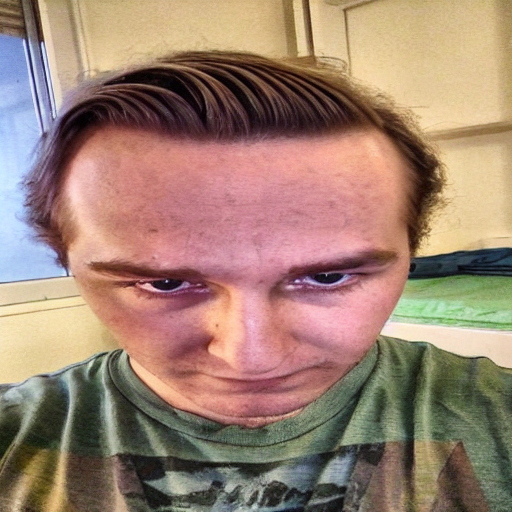

In [ ]:
from IPython.display import display
from PIL import Image
import json

meta_path = "/content/drive/MyDrive/AI_Trichologist/data/profiles/user_20260223_075109_087_meta.json"

saved_path, summary = run_tryon(meta_path)
print("✅ Saved:", saved_path)
print(json.dumps(summary, indent=2))
display(Image.open(saved_path))

In [ ]:
import os
from google.colab import userdata

key = userdata.get("GOOGLE_API_KEY")
if not key:
    raise RuntimeError("No secret named GOOGLE_API_KEY found in Colab Secrets.")
os.environ["GOOGLE_API_KEY"] = key
print("✅ GOOGLE_API_KEY loaded. length =", len(key))

✅ GOOGLE_API_KEY loaded. length = 39
